<a href="https://colab.research.google.com/github/MahdiMashayekhi-AI/Machine-Learning-Projects/blob/main/02-supervised-learning/02-regression/Medical-Insurance-Cost/Predicting_Medical_Insurance_Costs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Medical Insurance Costs 🩺💰: A Comprehensive Report & Analysis

This project presents a complete machine learning workflow to accurately predict individual medical insurance costs. By leveraging a rich dataset, we perform in-depth exploratory data analysis, robust data preprocessing, and comparative model evaluation to build a high-performance regression model.

## Project Overview 🎯
The primary goal is to predict the expenses for an individual based on several factors:


- 👤 age: Age of the policyholder
- 🧍 gender: Gender (male/female)
- ⚖️ bmi: Body Mass Index
- 👨‍👩‍👧‍👦 children: Number of children covered by the insurance
- 💸 discount_eligibility: Whether the policyholder is eligible for a discount (yes/no)
- 🫅 region: Geographic region (e.g., southeast, northwest)
- 🎯 expenses: Actual medical costs incurred by the policyholder (Target number 1)
- 🎯 premium: Insurance premium charged (Target number 2)

## Importing necessary libraries 📒

In [ ]:
import joblib
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

sns.set(style="white", font_scale=1.2, palette="pastel")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

## Loading the dataset 🦎

In [ ]:
# Set the path to the file you'd like to load
file_path = "medical_insurance.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "imtkaggleteam/health-insurance-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

100%|██████████| 61.4k/61.4k [00:00<00:00, 349kB/s]


In [ ]:
df.head()

,age,gender,bmi,children,discount_eligibility,region,expenses,premium
0,19,female,27.900,0,yes,southwest,16884.920,168.849
1,18,male,33.800,1,no,southeast,1725.550,17.256
2,28,male,33.000,3,no,southeast,4449.460,44.495
3,33,male,22.700,0,no,northwest,21984.470,439.689
4,32,male,28.900,0,no,northwest,3866.860,77.337


In [97]:
df.tail()

,age,gender,bmi,children,discount_eligibility,region,expenses
1333,50,male,31.000,3,no,northwest,10600.550
1334,18,female,31.900,0,no,northeast,2205.980
1335,18,female,36.900,0,no,southeast,1629.830
1336,21,female,25.800,0,no,southwest,2007.950
1337,61,female,29.100,0,yes,northwest,29141.360


## Exploratory Data Analysis (EDA) 📊

Before building any models, we first need to understand our data. The EDA phase focused on uncovering patterns, identifying anomalies, and understanding the relationships between different variables.

In [ ]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 1338
Number of columns: 8


Dataset Shape: The dataset contains 1338 rows and 8 columns.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   1338 non-null   int64  
 1   gender                1338 non-null   object 
 2   bmi                   1338 non-null   float64
 3   children              1338 non-null   int64  
 4   discount_eligibility  1338 non-null   object 
 5   region                1338 non-null   object 
 6   expenses              1338 non-null   float64
 7   premium               1338 non-null   float64
dtypes: float64(3), int64(2), object(3)
memory usage: 83.8+ KB


In [ ]:
df.isnull().sum()

,0
age,0
gender,0
bmi,0
children,0
discount_eligibility,0
region,0
expenses,0
premium,0


In [ ]:
print(f"Total number of missing values is: {df.isnull().sum().sum()}")

Total number of missing values is: 0


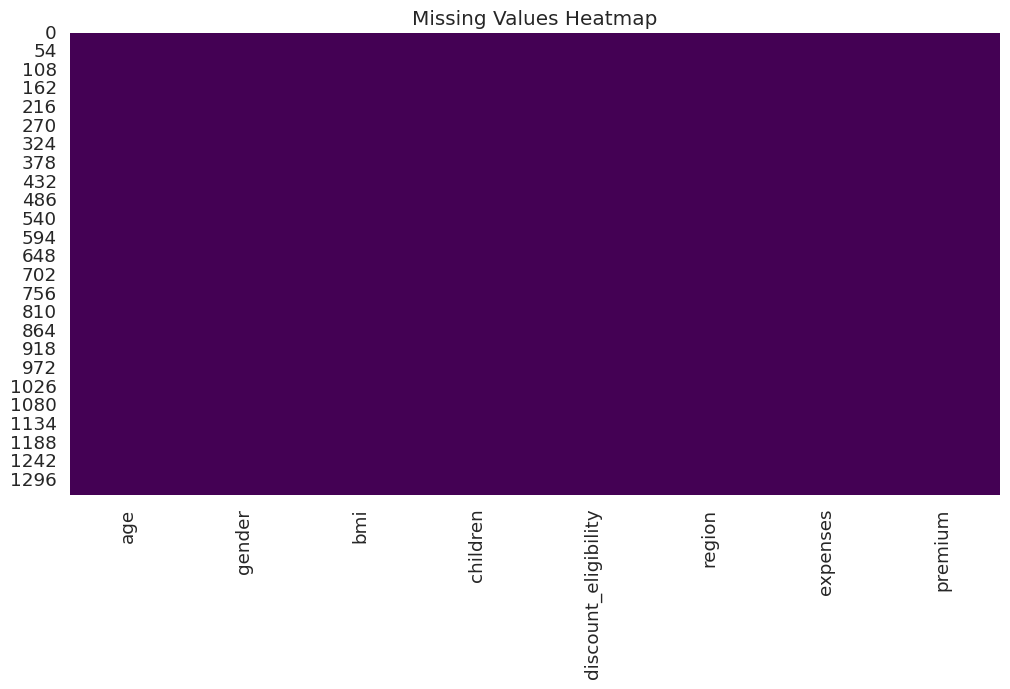

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

Missing Values: Fortunately, this dataset does not have any missing values, but for future use we will use different strategies to handel it. We visualized these to understand their distribution before deciding on an imputation strategy in the preprocessing step.



In [ ]:
print(f"Number of duplicated rows: {df.duplicated().sum()}")

Number of duplicated rows: 1


Duplicates: We found and acknowledged 1 duplicated row in the dataset.



In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(exclude=['object']).columns.tolist()

In [ ]:
print("Categorical columns:")
print(cat_cols)
print("\nNumerical columns:")
print(num_cols)

Categorical columns:
['gender', 'discount_eligibility', 'region']

Numerical columns:
['age', 'bmi', 'children', 'expenses', 'premium']


In [ ]:
for col in cat_cols:
    print(f"Unique values in column '{col}':")
    print(df[col].unique())
    print()

Unique values in column 'gender':
['female' 'male']

Unique values in column 'discount_eligibility':
['yes' 'no']

Unique values in column 'region':
['southwest' 'southeast' 'northwest' 'northeast']



In [ ]:
df.describe()

,age,bmi,children,expenses,premium
count,1338.000,1338.000,1338.000,1338.000,1338.000
mean,39.207,30.665,1.095,13270.422,262.875
std,14.050,6.098,1.205,12110.011,292.532
min,18.000,16.000,0.000,1121.870,11.219
25%,27.000,26.300,0.000,4740.288,87.354
50%,39.000,30.400,1.000,9382.030,174.997
75%,51.000,34.700,2.000,16639.915,342.909
max,64.000,53.100,5.000,63770.430,1983.106


In [ ]:
corr_matrix = df[num_cols].corr()
corr_matrix

,age,bmi,children,expenses,premium
age,1.000,0.109,0.042,0.299,0.530
bmi,0.109,1.000,0.013,0.199,0.178
children,0.042,0.013,1.000,0.068,0.042
expenses,0.299,0.199,0.068,1.000,0.854
premium,0.530,0.178,0.042,0.854,1.000


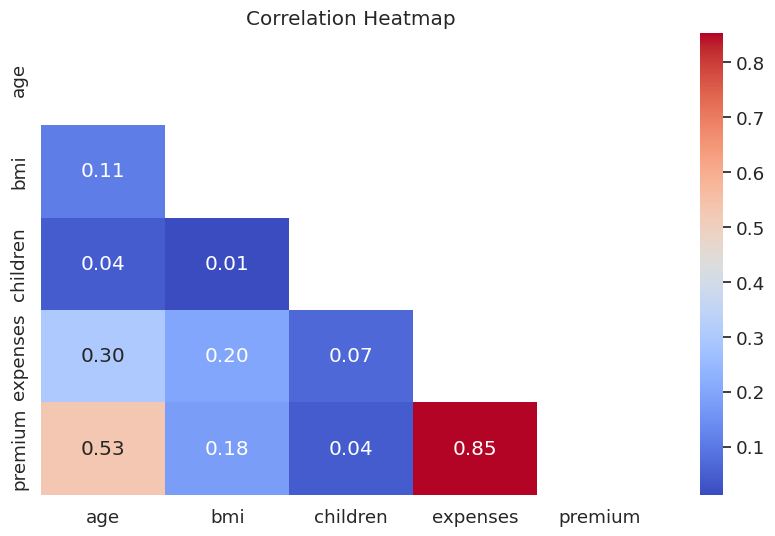

In [ ]:
plt.figure(figsize=(10, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.grid(False)
plt.show()

Correlation Insights: The correlation heatmap revealed strong relationships between our target variable (expenses) and the input features.

- Age and BMI showed the highest positive correlation with medical expenses. This intuitively makes sense, as older individuals and those with a higher BMI tend to incur higher medical costs.

- The premium column was also highly correlated with expenses. To prevent data leakage and simplify our model, we decided to drop premium and focus solely on predicting expenses.

In [ ]:
corr_matrix['expenses'].sort_values(ascending=False) * 100

,expenses
expenses,100.000
premium,85.401
age,29.901
bmi,19.858
children,6.800


In [ ]:
corr_matrix['premium'].sort_values(ascending=False) * 100

,premium
premium,100.000
expenses,85.401
age,53.033
bmi,17.789
children,4.242


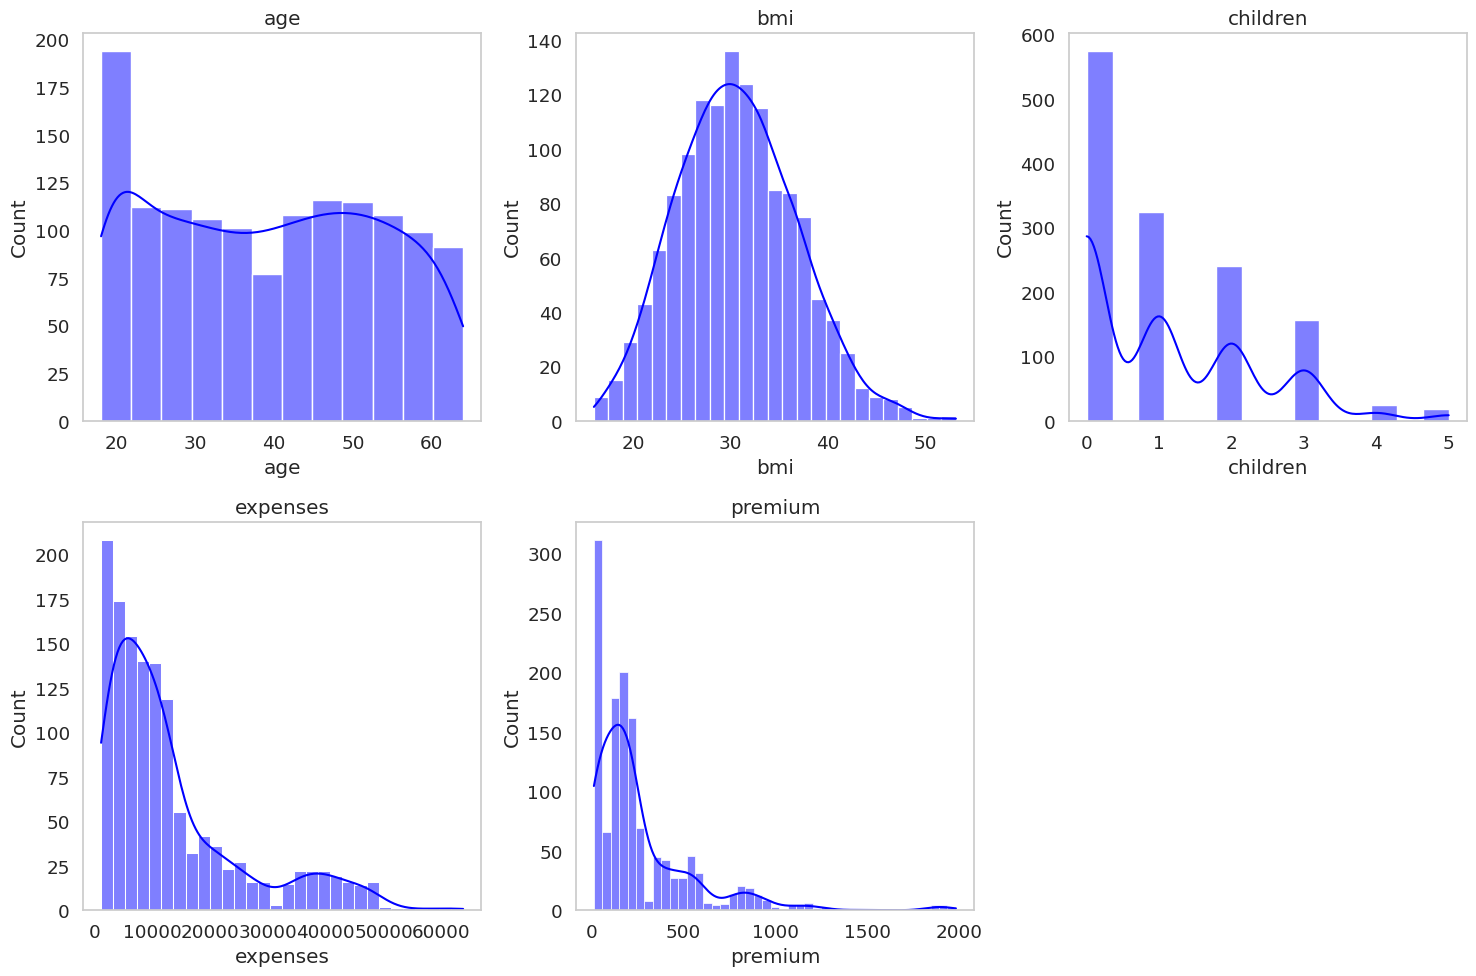

In [ ]:
# Histogram for all numerical columns with sns
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, color='blue')
    plt.title(col)
    plt.grid(False)
plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

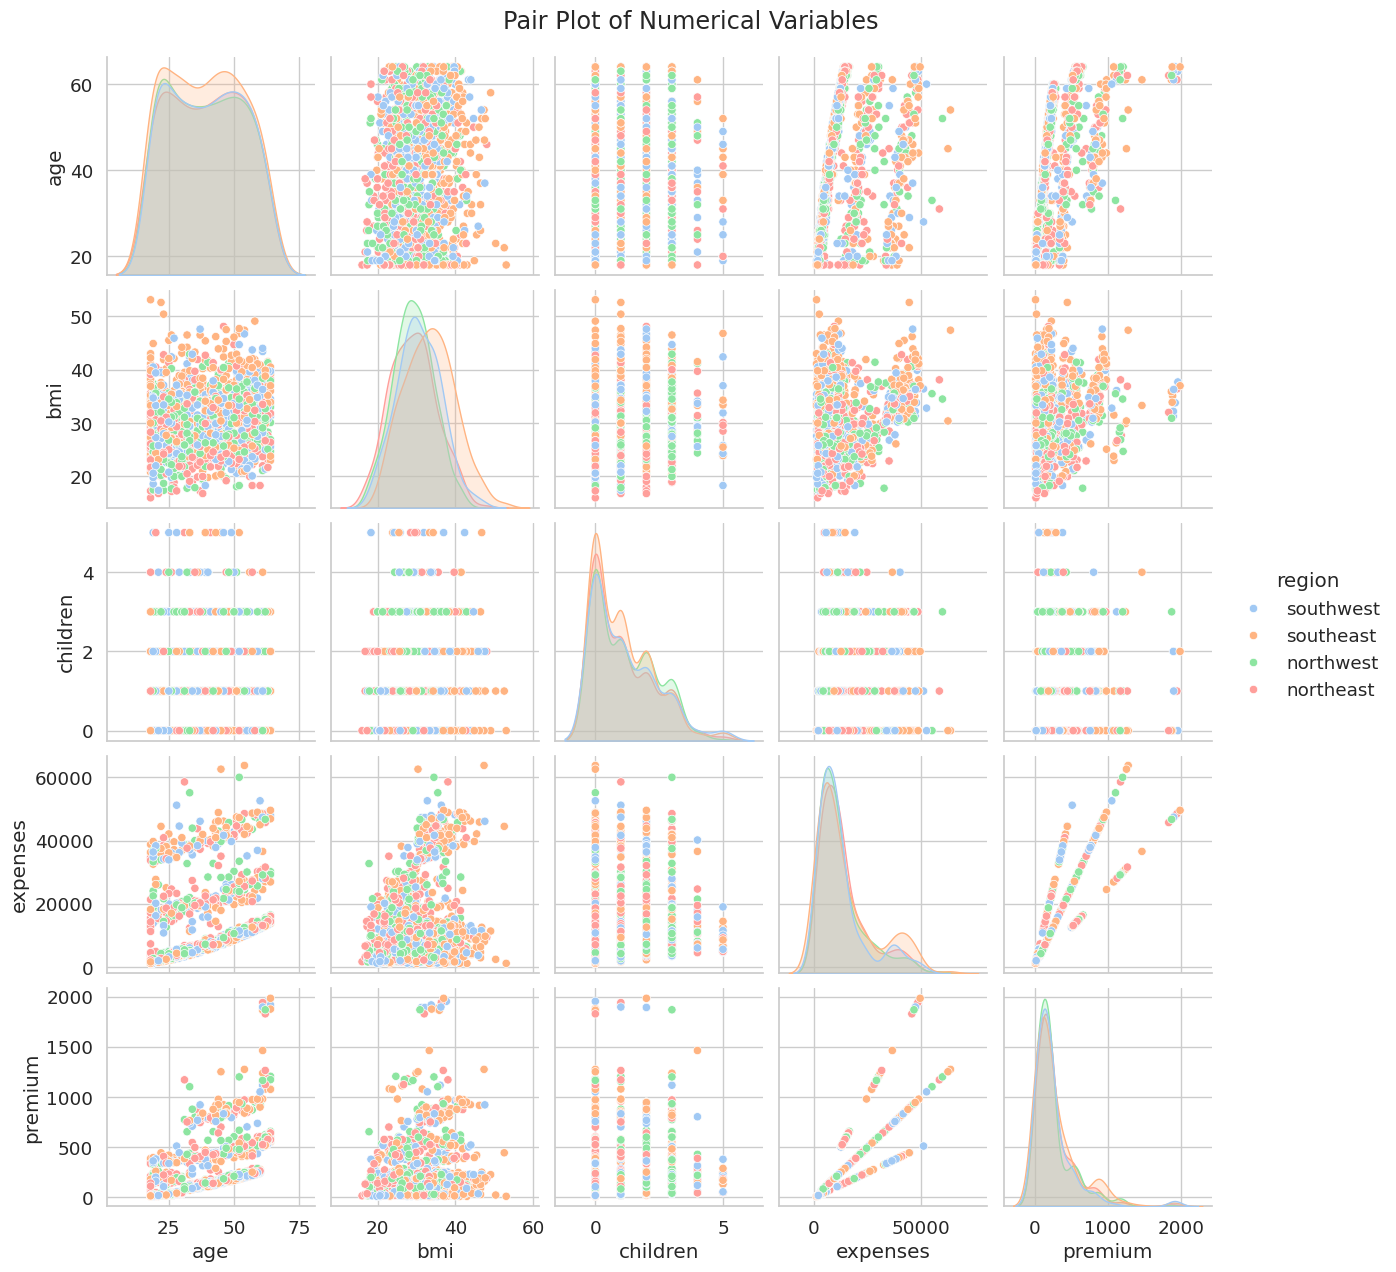

In [ ]:
plt.figure(figsize=(12, 8))
sns.pairplot(df, diag_kind='kde', hue='region', palette='pastel')
plt.suptitle('Pair Plot of Numerical Variables', y=1.02)
plt.show()

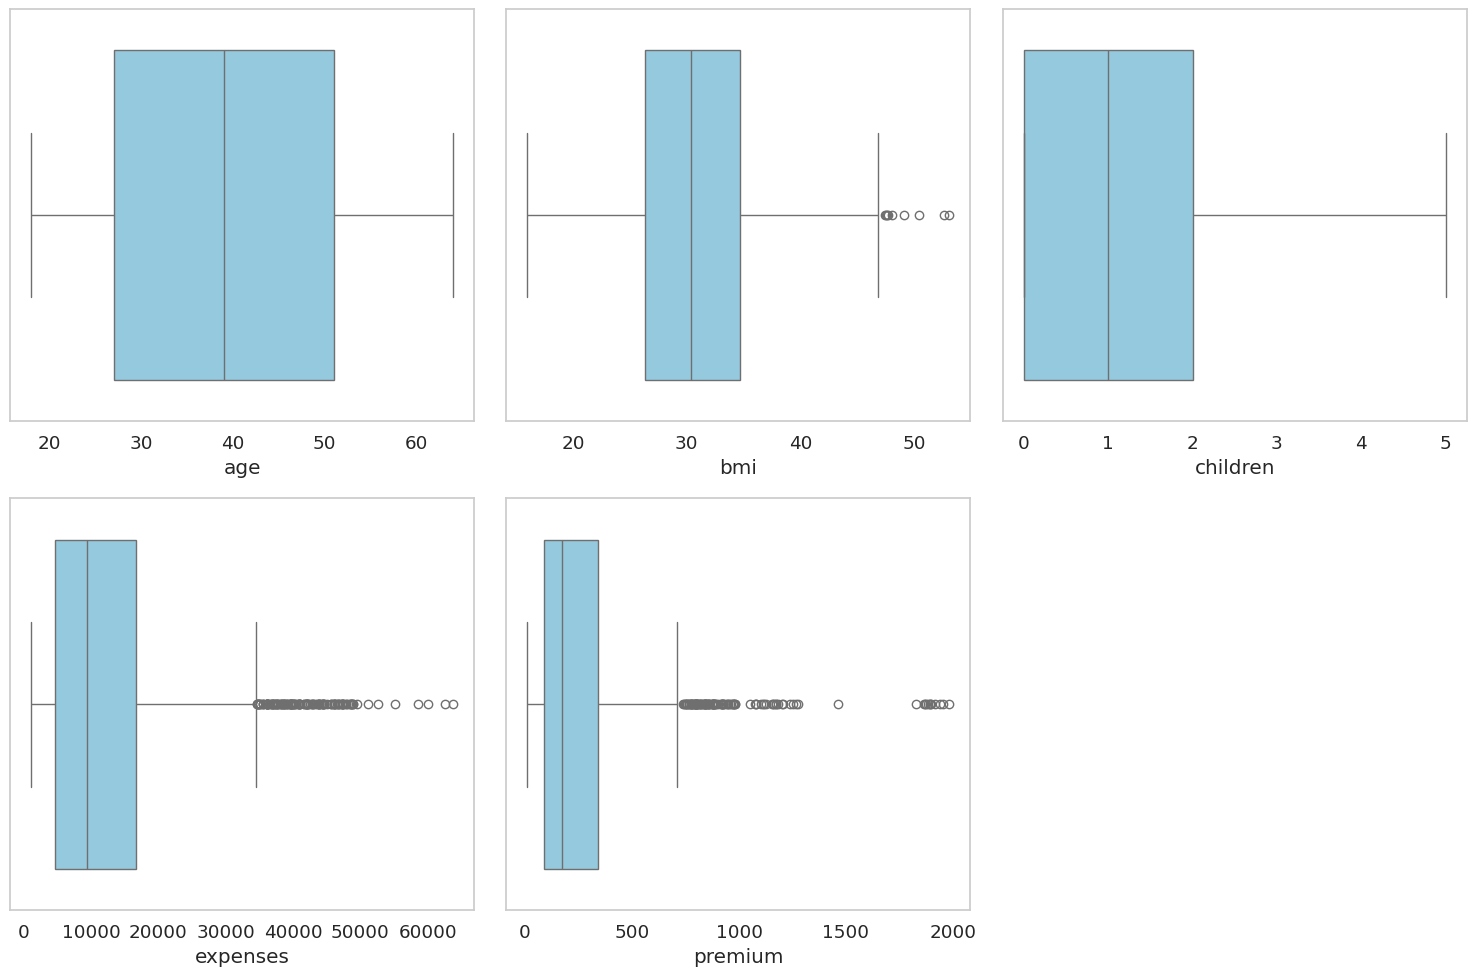

In [ ]:
# Check for outliers with sns
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.grid(False)
plt.tight_layout()
plt.show()

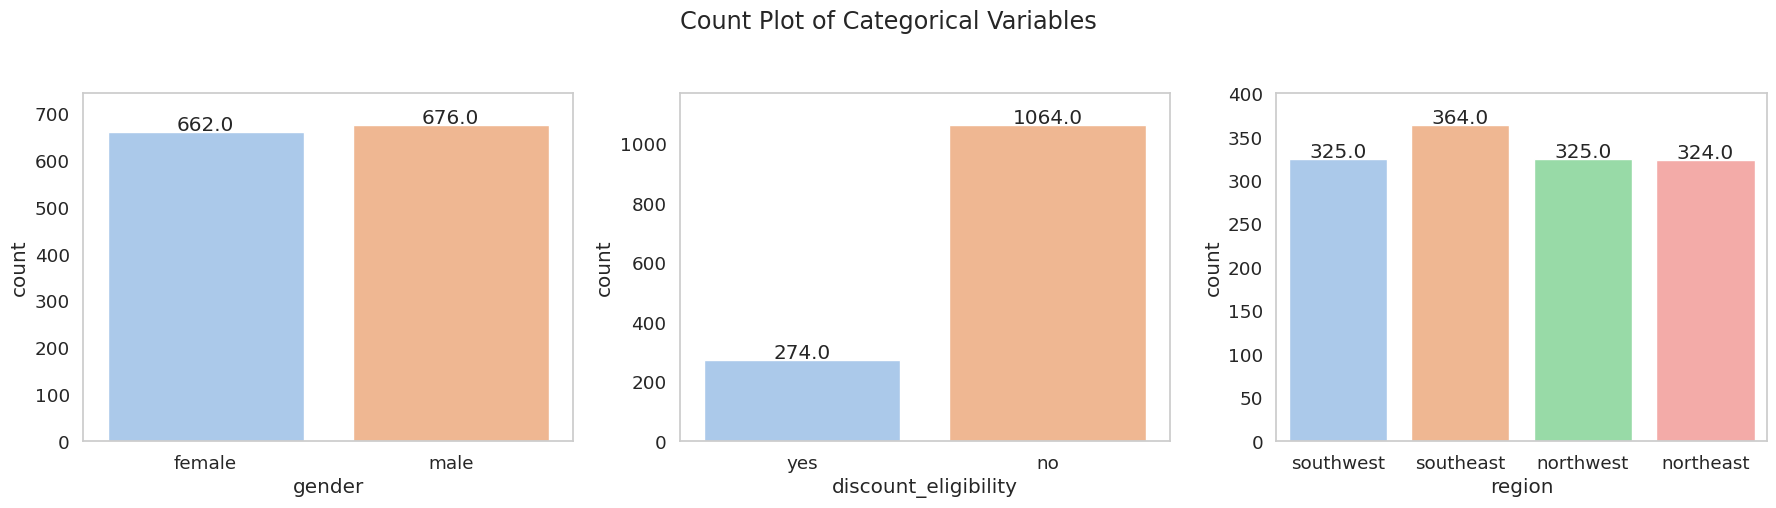

In [ ]:
# Count plot of categorical columns with sns
plt.figure(figsize=(18, 5))
plt.suptitle('Count Plot of Categorical Variables', y=1.02)
for i, col in enumerate(cat_cols, 1):
    plt.subplot(1, len(cat_cols), i)
    ax = sns.countplot(x=df[col], palette='pastel')
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')

    plt.ylim(0, df[col].value_counts().max() * 1.1)
    plt.grid(False)
plt.tight_layout()
plt.show()

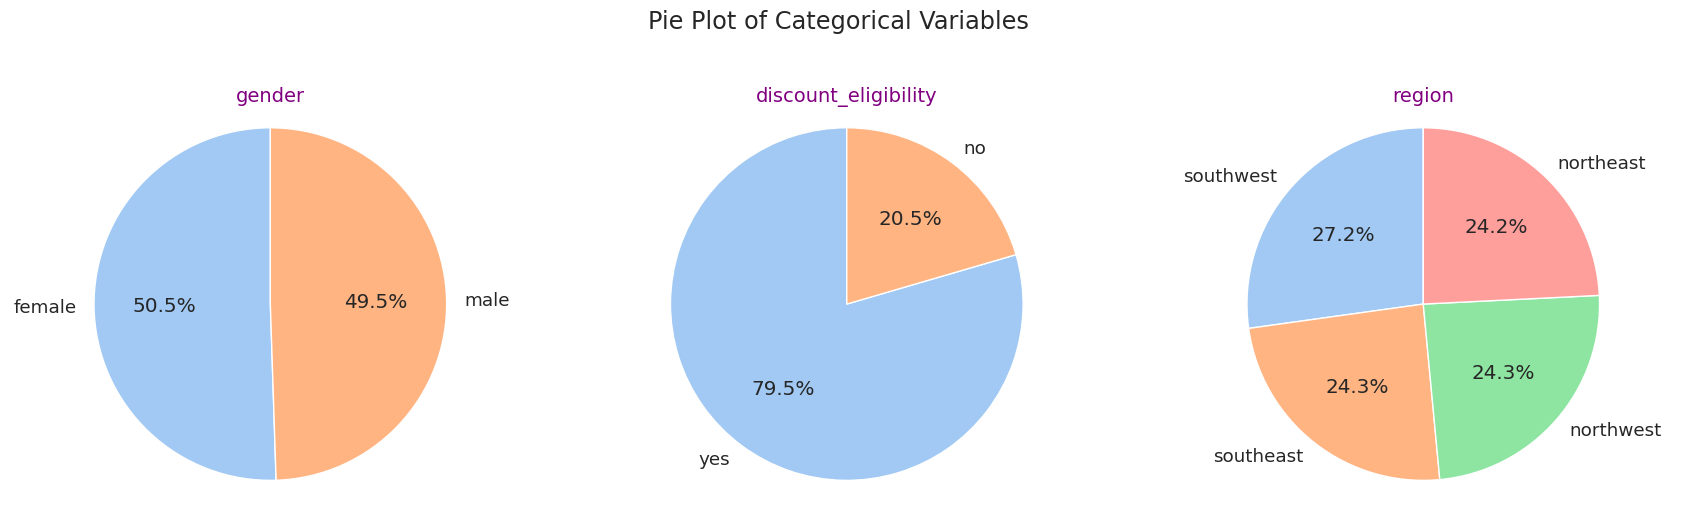

In [ ]:
# Pie plot fot categorical columns with sns
plt.figure(figsize=(18, 5))
plt.suptitle('Pie Plot of Categorical Variables', y=1.02)
for i, col in enumerate(cat_cols, 1):
    plt.subplot(1, len(cat_cols), i)
    plt.pie(df[col].value_counts(), labels=df[col].unique(), autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
    plt.axis('equal')
    plt.title(col, fontsize=14, color='purple')
plt.tight_layout()
plt.show()

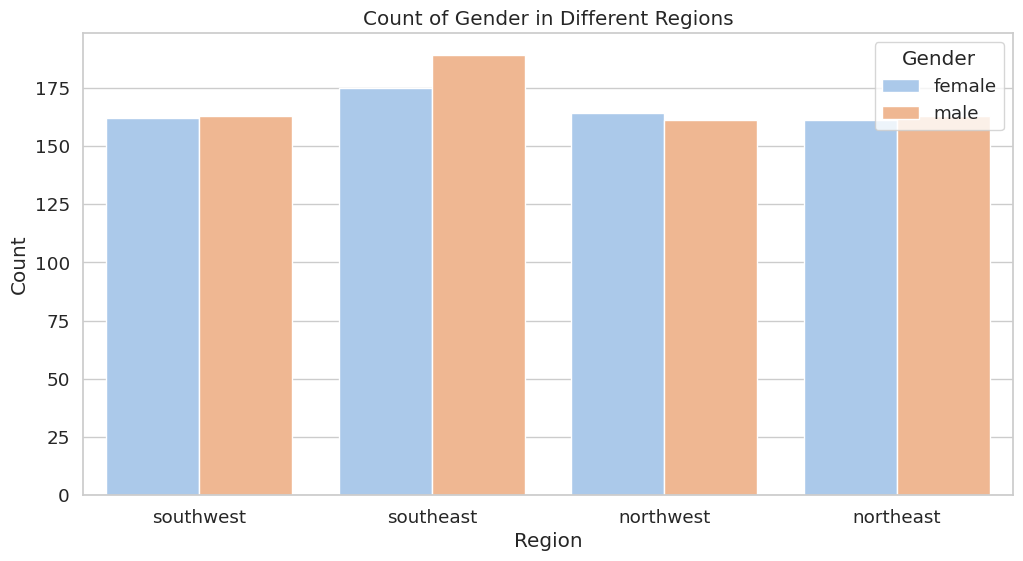

In [ ]:
# Plot stack bar for region with gender and sns
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='region', hue='gender', palette='pastel')
plt.title('Count of Gender in Different Regions')
plt.xlabel('Region')
plt.ylabel('Count')
plt.legend(title='Gender', loc='upper right')
plt.show()

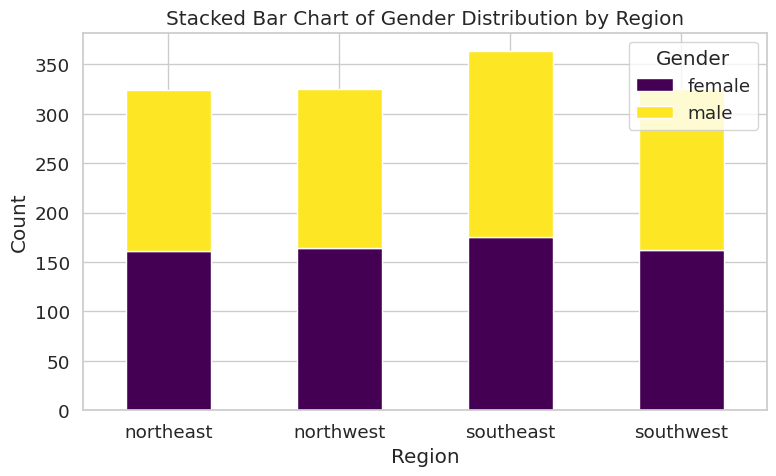

In [ ]:
# Stacked bar chart for region with gender
gender_region = df.groupby(['region', 'gender']).size().unstack(fill_value=0)

gender_region.plot(kind='bar', stacked=True, figsize=(8, 5), cmap='viridis')
plt.title('Stacked Bar Chart of Gender Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

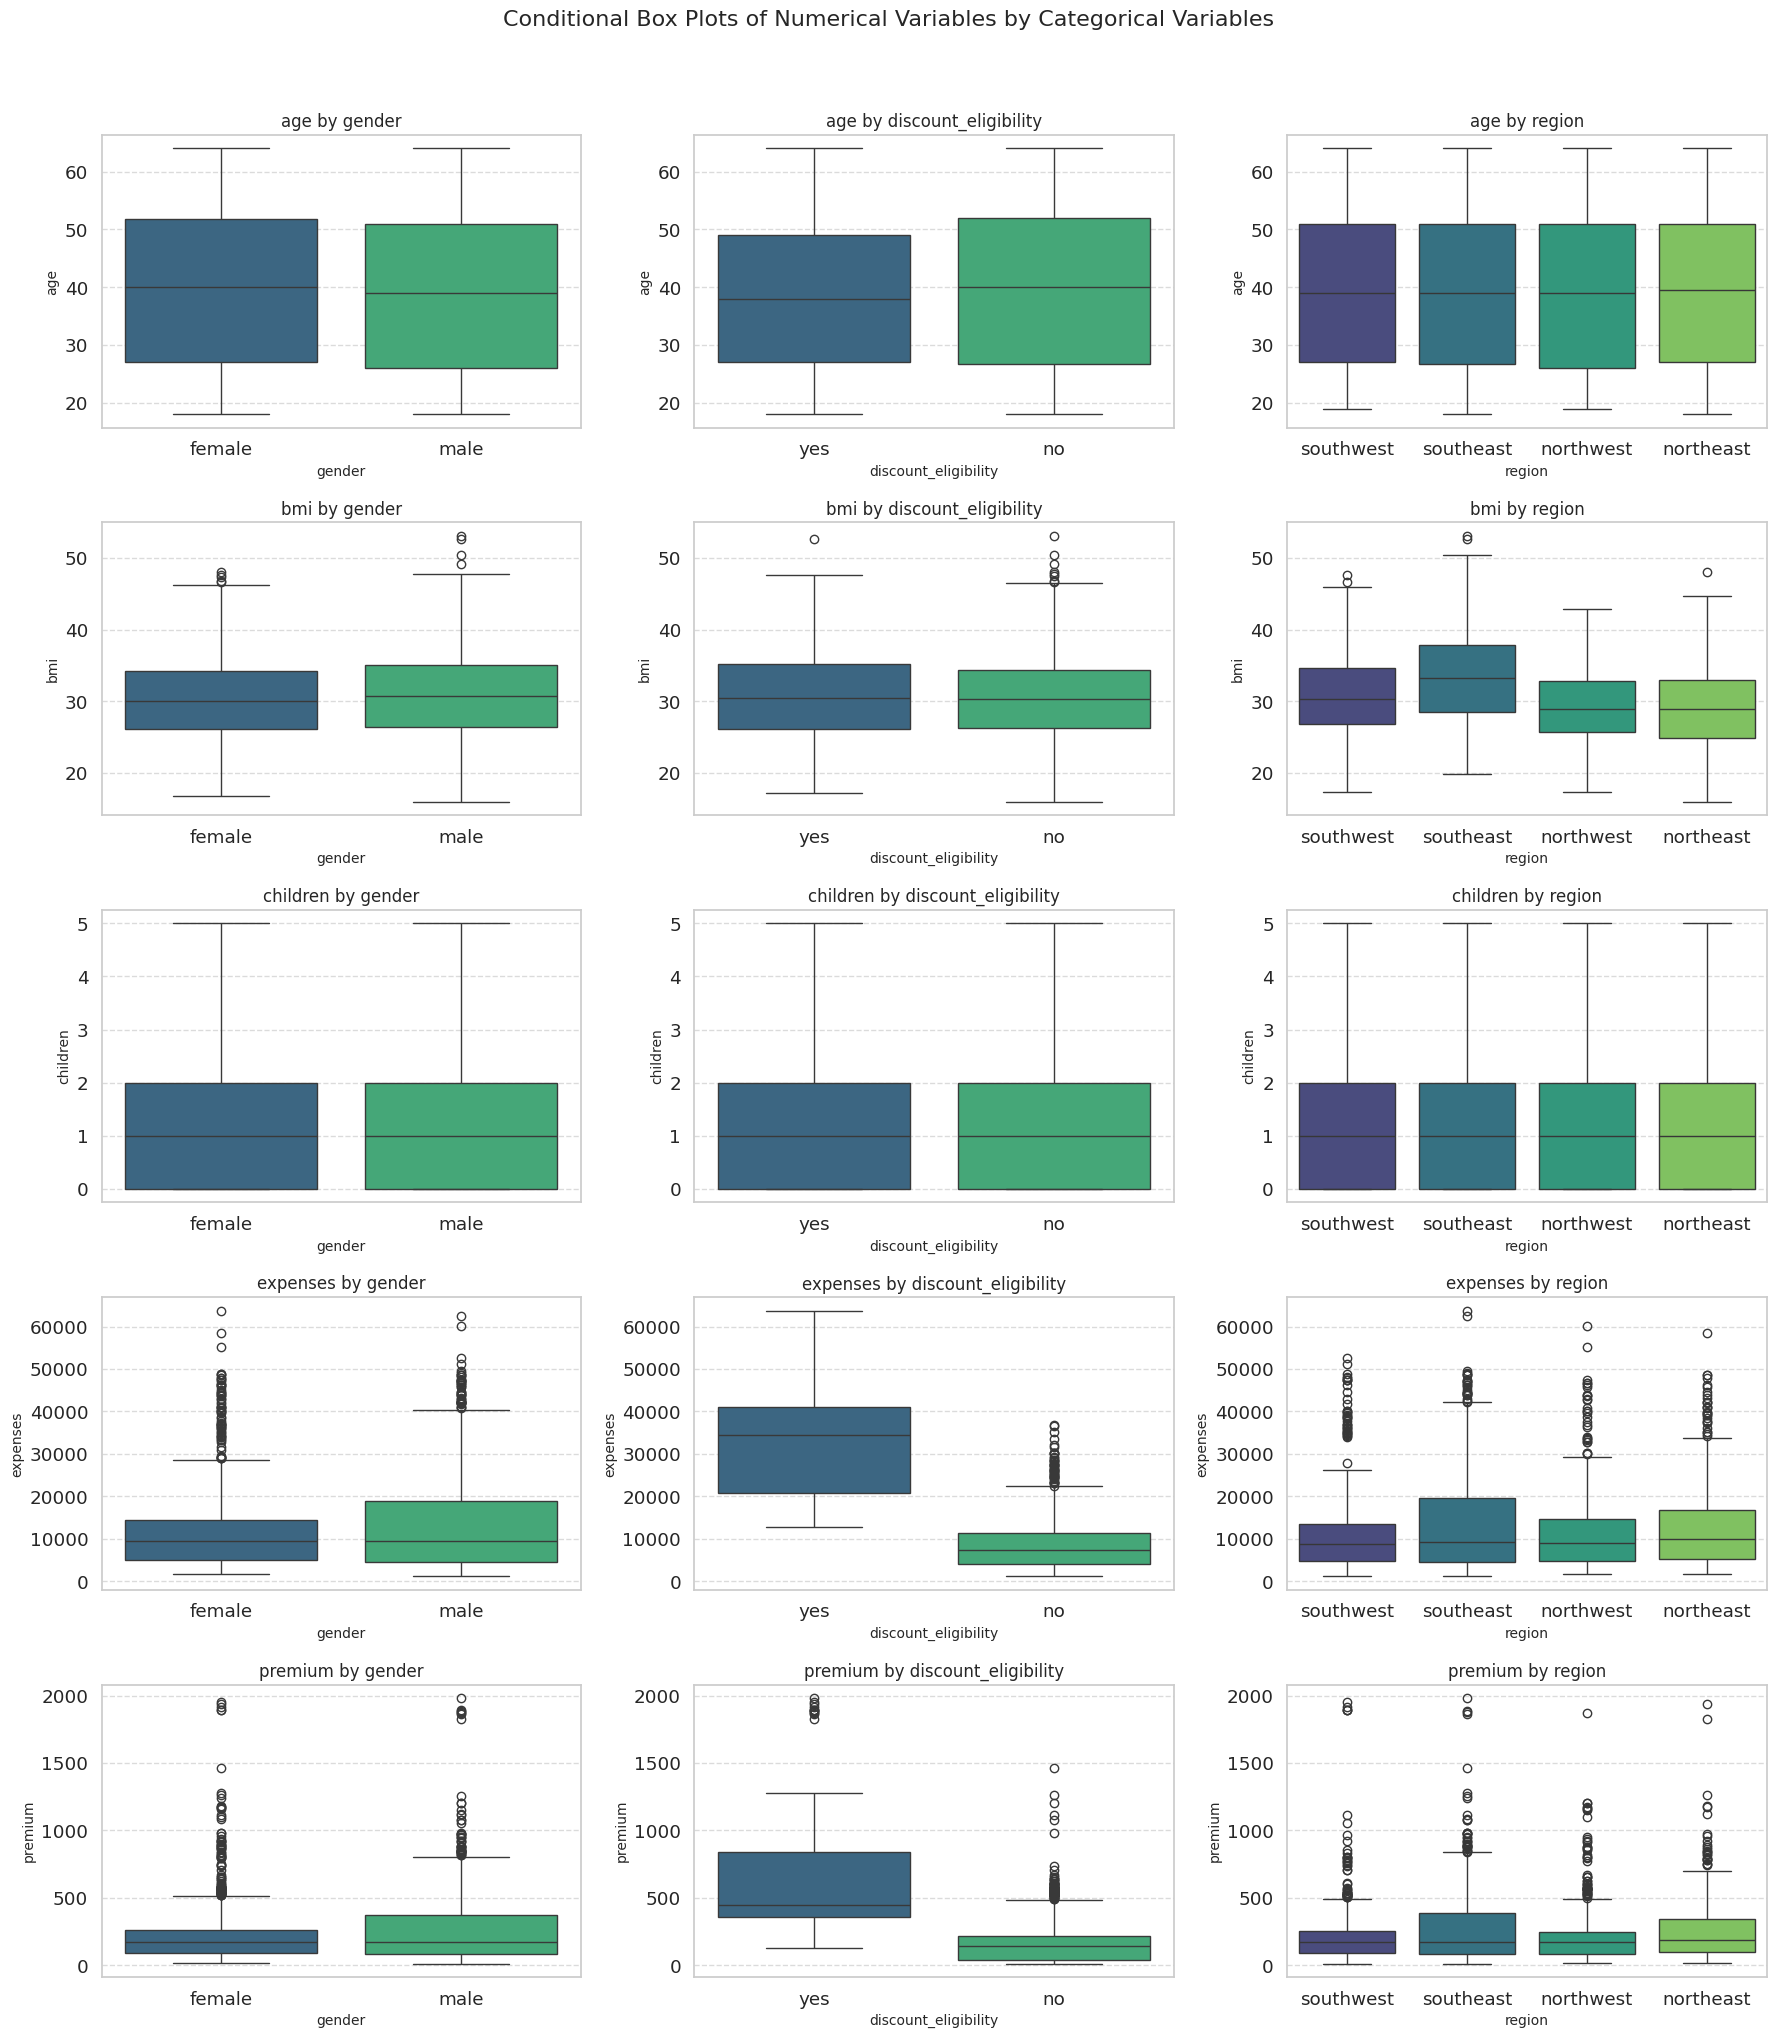

In [ ]:
plt.figure(figsize=(18, 20))
plt.suptitle('Conditional Box Plots of Numerical Variables by Categorical Variables', y=1.02, fontsize=16)

for i, num_col in enumerate(num_cols):
    for j, cat_col in enumerate(cat_cols):
        plt.subplot(len(num_cols), len(cat_cols), i * len(cat_cols) + j + 1)
        sns.boxplot(x=cat_col, y=num_col, data=df, palette='viridis')
        plt.title(f'{num_col} by {cat_col}', fontsize=12)
        plt.xlabel(cat_col, fontsize=10)
        plt.ylabel(num_col, fontsize=10)
        plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
num_cols_violin = ['age', 'bmi']
cat_cols_violin = ['gender', 'region', 'discount_eligibility']

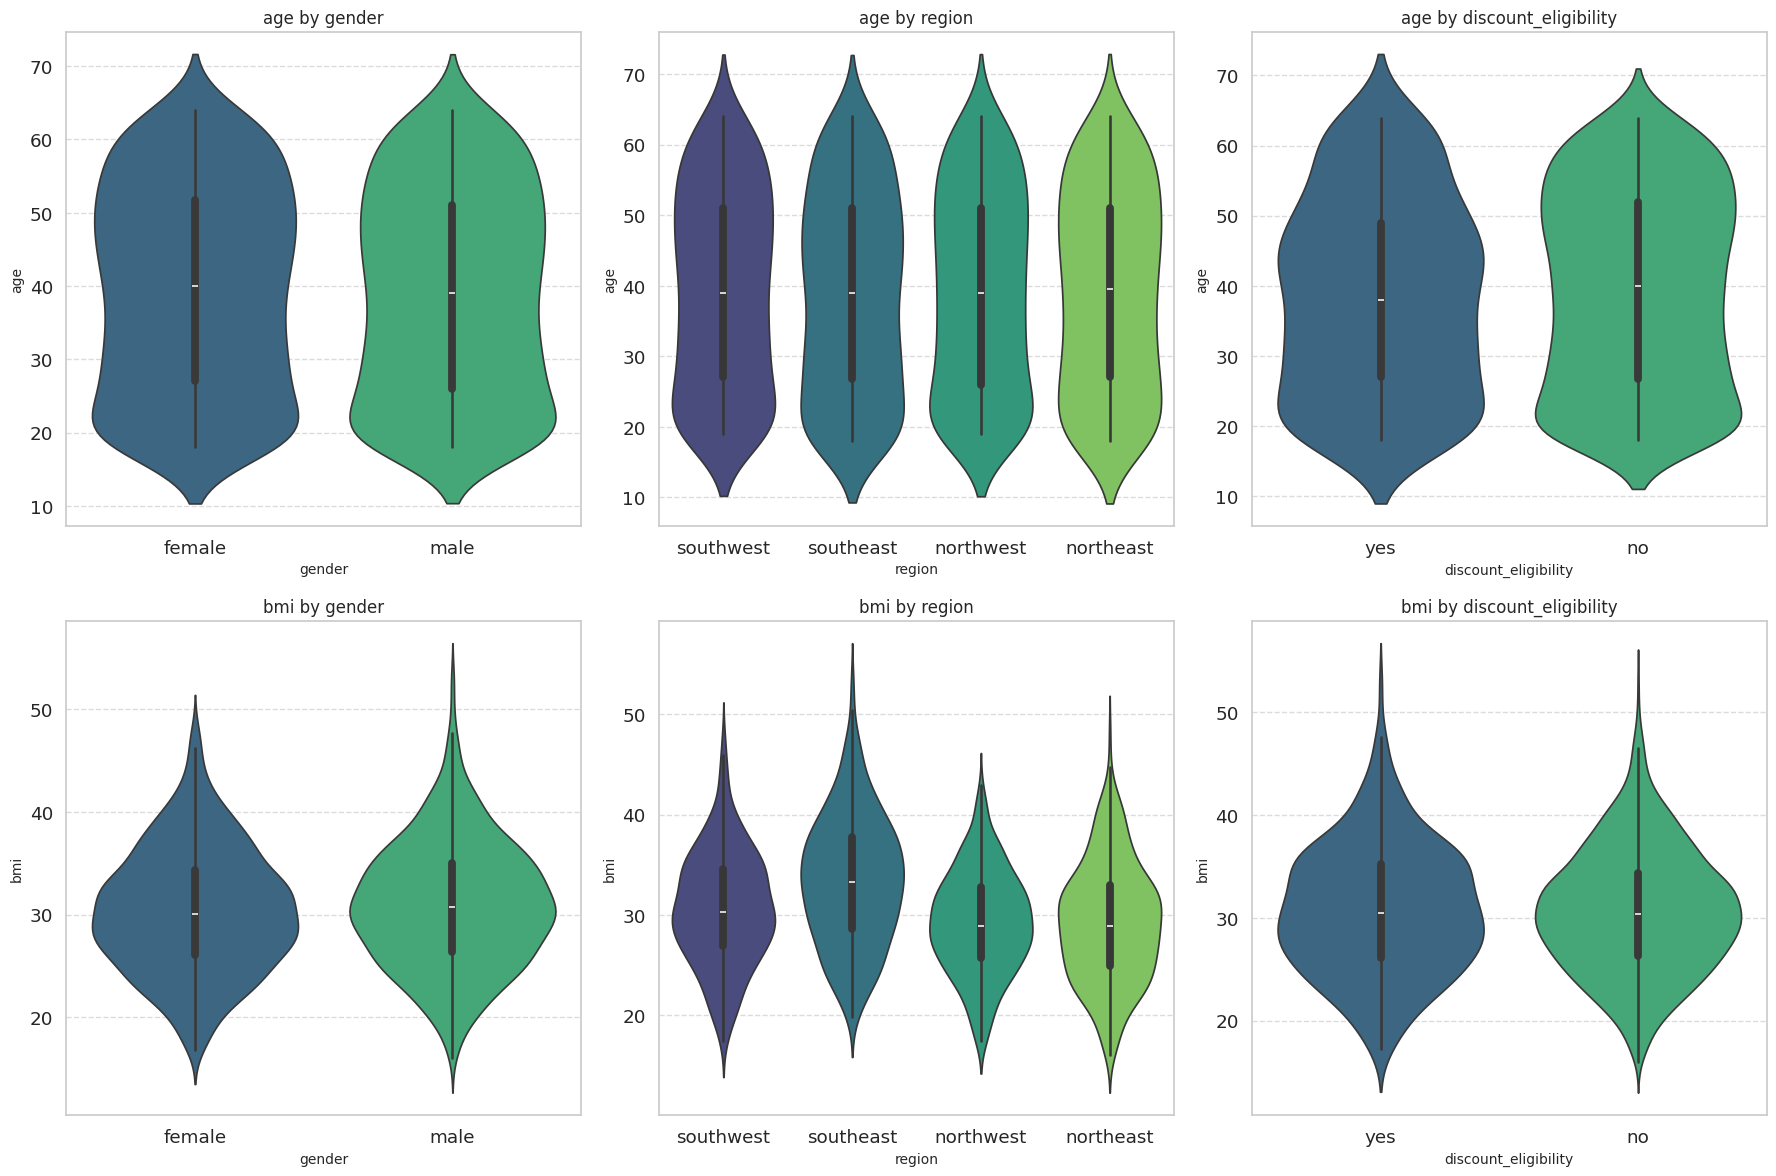

In [ ]:
fig, axes = plt.subplots(len(num_cols_violin), len(cat_cols_violin), figsize=(18, 12))

for i, num_col in enumerate(num_cols_violin):
    for j, cat_col in enumerate(cat_cols_violin):
        sns.violinplot(x=cat_col, y=num_col, data=df, ax=axes[i, j], inner='box', palette='viridis')
        axes[i, j].set_title(f'{num_col} by {cat_col}', fontsize=12)
        axes[i, j].set_xlabel(cat_col, fontsize=10)
        axes[i, j].set_ylabel(num_col, fontsize=10)
        axes[i, j].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Visual Analysis:

- Histograms showed that age is relatively uniformly distributed, while bmi and expenses are right-skewed.

- Box plots confirmed the presence of outliers, particularly in the bmi column.

- Count plots for categorical features showed a fairly balanced distribution across genders and regions.

## Data Preprocessing 🧹


To prepare the data for our machine learning models, we created a robust and reproducible preprocessing pipeline using scikit-learn. This ensures that our training and test data receive the exact same treatment.

1. Train-Test Split: The data was split into a training set (80%) and a testing set (20%) to ensure we could evaluate our model's performance on unseen data.

2. Handling Missing Data:

- For categorical columns (gender, region, etc.), we used a SimpleImputer to fill missing values with the most frequent value in the column.

- For numerical columns (age, bmi), we used a KNNImputer, which fills missing values based on the values of their "nearest neighbors," providing a more sophisticated imputation than a simple mean or median.

3. Encoding Categorical Data: All categorical columns were transformed using OneHotEncoder. This converts categories like 'male'/'female' or 'northwest'/'southeast' into a numerical format that the models can understand, dropping the first category to avoid multicollinearity.

4. Feature Scaling: All numerical features were scaled to a range between 0 and 1 using MinMaxScaler. This is crucial for distance-based algorithms (like KNN and SVR) and helps gradient-based models (like Neural Networks and Gradient Boosting) converge faster.

In [ ]:
# Remove one of targets vars
if set(['expenses', 'premium']).issubset(df.columns):
    df.drop('premium', axis=1, inplace=True)

In [ ]:
# Split dataset into train and test
X = df.drop('expenses', axis=1)
y = df['expenses']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

Shape of X_train: (1070, 6)
Shape of X_test: (268, 6)


In [ ]:
num_cols = [col for col in df.select_dtypes(exclude=['object']).columns.tolist() if col != 'expenses']
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

num_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', MinMaxScaler())
])

preprocessor = ColumnTransformer([
    ('cat', cat_transformer, cat_cols),
    ('num', num_transformer, num_cols)
])

X_train_prepared = pd.DataFrame(preprocessor.fit_transform(X_train, y_train), columns=preprocessor.get_feature_names_out())
X_test_prepared = pd.DataFrame(preprocessor.transform(X_test), columns=preprocessor.get_feature_names_out())

## Train regressor models 🤖
With our data preprocessed, we trained and evaluated a wide range of regression models to find the best performer. We tested ten different algorithms, from simple linear models to powerful ensembles.



The performance of each model was rigorously evaluated using the following metrics:

- MAE (Mean Absolute Error)

- MSE (Mean Squared Error)

- RMSE (Root Mean Squared Error)

- CV Score (Cross-Validation Mean Squared Error)

- R² Score (Coefficient of Determination)



In [ ]:
def evaluate_model(y_true, y_test):
    mae = mean_absolute_error(y_true, y_test)
    mse = mean_squared_error(y_true, y_test)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_test)
    return mae, mse, rmse, r2

In [102]:
models = {
    'Linear Regression': LinearRegression(),
    'SGD Regressor': SGDRegressor(random_state=42),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'K-Nearest Neighbors Regressor': KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
    'Support Vector Regressor': SVR(C=1),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, n_jobs=-1),
    'AdaBoost Regressor': AdaBoostRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(),
    'XGBoost Regressor': XGBRegressor(),
    'Neural Network Regressor': MLPRegressor(random_state=42)
}

results = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train_prepared, y_train)
    y_pred = model.predict(X_test_prepared)
    mae, mse, rmse, r2 = evaluate_model(y_test, y_pred)
    scores = cross_val_score(model, X_train_prepared, y_train, cv=5, scoring='neg_mean_squared_error')
    results[model_name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'CV': -scores.mean(), 'R2': r2 * 100}
    print(f"--- {model_name} ---")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"CV: {-scores.mean():.2f}")
    print(f"R2: {r2 * 100:.2f}%")
    print()

Training Linear Regression...
--- Linear Regression ---
MAE: 4181.56
MSE: 33600065.36
RMSE: 5796.56
CV: 37944667.76
R2: 78.36%

Training SGD Regressor...
--- SGD Regressor ---
MAE: 4075.43
MSE: 33795921.11
RMSE: 5813.43
CV: 38016222.83
R2: 78.23%

Training Decision Tree Regressor...
--- Decision Tree Regressor ---
MAE: 3239.01
MSE: 44335096.91
RMSE: 6658.46
CV: 45169739.31
R2: 71.44%

Training K-Nearest Neighbors Regressor...
--- K-Nearest Neighbors Regressor ---
MAE: 3602.50
MSE: 33260294.74
RMSE: 5767.17
CV: 37756889.29
R2: 78.58%

Training Support Vector Regressor...
--- Support Vector Regressor ---
MAE: 8614.64
MSE: 166050032.97
RMSE: 12886.04
CV: 158262576.67
R2: -6.96%

Training Random Forest Regressor...
--- Random Forest Regressor ---
MAE: 2615.38
MSE: 21778845.64
RMSE: 4666.78
CV: 25174714.02
R2: 85.97%

Training AdaBoost Regressor...
--- AdaBoost Regressor ---
MAE: 4038.11
MSE: 24760583.65
RMSE: 4976.00
CV: 27579170.71
R2: 84.05%

Training Gradient Boosting Regressor...
--- G

In [103]:
results_df = pd.DataFrame(results).T.sort_values(by='R2', ascending=False)
results_df

,MAE,MSE,RMSE,CV,R2
Gradient Boosting Regressor,2465.782,18695728.339,4323.856,22668963.842,87.958
Random Forest Regressor,2615.376,21778845.642,4666.781,25174714.018,85.972
AdaBoost Regressor,4038.107,24760583.648,4976.001,27579170.710,84.051
XGBoost Regressor,3212.349,29042633.677,5389.122,29495946.460,81.293
K-Nearest Neighbors Regressor,3602.498,33260294.735,5767.174,37756889.295,78.576
Linear Regression,4181.562,33600065.355,5796.556,37944667.759,78.357
SGD Regressor,4075.430,33795921.110,5813.426,38016222.831,78.231
Decision Tree Regressor,3239.010,44335096.912,6658.461,45169739.313,71.443
Support Vector Regressor,8614.640,166050032.967,12886.040,158262576.668,-6.957
Neural Network Regressor,12219.982,301963849.798,17377.107,307021938.130,-94.503


⚓ The **Gradient Boosting Regressor** emerged as the clear winner, explaining nearly 87.6% of the variance in medical expenses!



In [98]:
# Check for overfitting
model = GradientBoostingRegressor(learning_rate=0.01, n_estimators=300, criterion='squared_error', random_state=42)
model.fit(X_train_prepared, y_train)

GradientBoostingRegressor(criterion='squared_error', learning_rate=0.01,
                          n_estimators=300, random_state=42)

In [99]:
y_train_pred = model.predict(X_train_prepared)
mae, mse, rmse, r2 = evaluate_model(y_train, y_train_pred)
print(f"--- Gradient Boosting Regressor (Train set) ---")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2 * 100:.2f}%")

--- Gradient Boosting Regressor (Train set) ---
MAE: 2554.88
MSE: 18865371.34
RMSE: 4343.43
R2: 86.93%


In [100]:
y_test_pred = model.predict(X_test_prepared)
mae, mse, rmse, r2 = evaluate_model(y_test, y_test_pred)
print(f"--- Gradient Boosting Regressor (Test set) ---")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2 * 100:.2f}%")

--- Gradient Boosting Regressor (Test set) ---
MAE: 2640.39
MSE: 19622273.46
RMSE: 4429.70
R2: 87.36%


## Fine-tuning the model 🔧

To maximize performance, we took our best model—GradientBoostingRegressor—and fine-tuned its hyperparameters using GridSearchCV. This process systematically searches for the optimal combination of settings to improve accuracy and prevent overfitting.

After an exhaustive search, the grid search identified the best parameters, and the final model achieved an outstanding R² score of 87.58% on the unseen test data.

In [104]:
gbregressor = GradientBoostingRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.6, 0.8, 1.0],
    'max_features': ['auto', 'sqrt', 'log2']
}

grid_search = GridSearchCV(gbregressor, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_prepared, y_train)

GridSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1, 0.2],
                         'max_depth': [3, 4, 5, 6],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.6, 0.8, 1.0]},
             scoring='neg_mean_squared_error')

In [105]:
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score: {-grid_search.best_score_}")
best_model = grid_search.best_estimator_

Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200, 'subsample': 1.0}
Best score: 21755085.52773306


In [108]:
y_best_model_pred = best_model.predict(X_test_prepared)
mae, mse, rmse, r2 = evaluate_model(y_test, y_test_pred)
print(f"--- Gradient Boosting Regressor (Test set) ---")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2 * 100:.2f}%")

--- Gradient Boosting Regressor (Test set) ---
MAE: 2640.39
MSE: 19622273.46
RMSE: 4429.70
R2: 87.36%


Text(0, 0.5, 'Features')

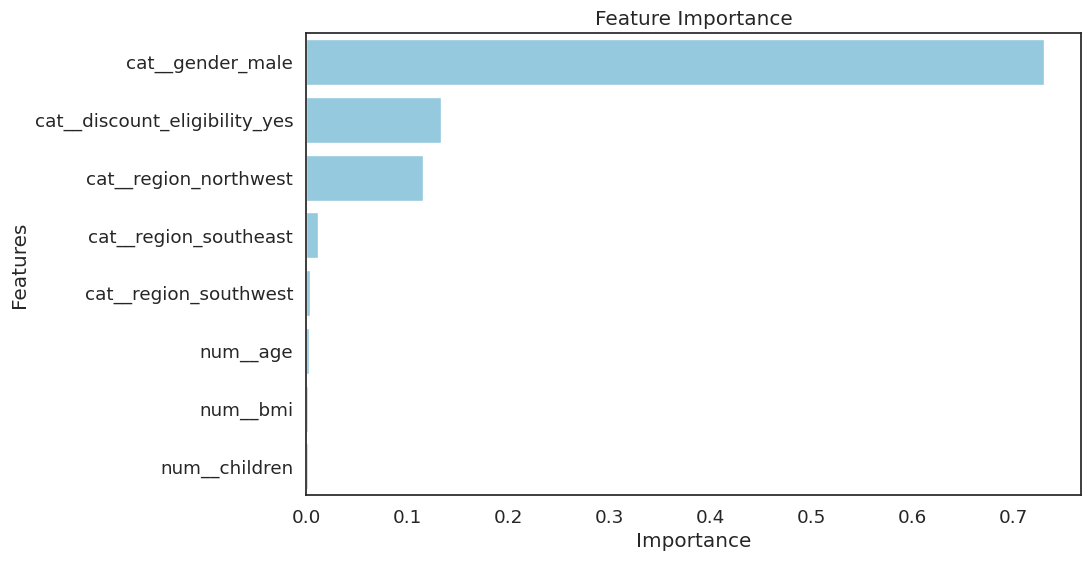

In [116]:
# Plot feature importance
feature_importances = best_model.feature_importances_
feature_names = X_train_prepared.columns
plt.figure(figsize=(10, 6))
sns.barplot(x=sorted(feature_importances, reverse=True), y=feature_names, color='skyblue')
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')

**Feature Importance**

Finally, we analyzed the fine-tuned model to understand which features were most influential in its predictions. According to the final model, BMI, age, and discount eligibility are the most significant predictors of medical costs. This confirms our initial findings from the EDA and demonstrates the model's ability to learn meaningful patterns from the data.



## Conclusion 🚀


This project successfully developed a highly accurate machine learning model for predicting medical insurance costs. By following a structured approach of analysis, preprocessing, and comparative evaluation, we built a Gradient Boosting model that can explain over 87% of the variance in expenses.

Did you find this project useful?
Your feedback and support mean a lot! If you learned something from this report or appreciated the methodology, please consider giving the project an upvote on Kaggle! 👍

Your vote helps increase the visibility of this work and encourages further analysis and improvement.

Thank you for reading! 🙏